## The Game-of-Thrones graph

![](img/GoT.jpg)

---

### Get prepared

#### Installations

py -m pip install pandas  
py -m pip install networkx  
py -m pip install matplotlib

#### Imports

In [1]:
import networkx as nx
import pandas as pd
pd.options.display.max_rows = 400
import matplotlib.pyplot as plt
from pprint import pprint
import json

---

### The *Game of Thrones* dataset

#### *GoT* Network

The network data that we're going to use in this lesson is taken from Andrew Beveridge and Jie Shan's paper, ["Network of Thrones."](https://www.maa.org/sites/default/files/pdf/Mathhorizons/NetworkofThrones%20%281%29.pdf)

These researchers calculated how many times each Game of Thrones character appeared within 15 words of another character in *A Storm of Swords*, the third book in the series.

| Network Element      | GOT |         
| :-------------: |:-------------:| 
| Node    | GOT character | 
| Edge     | Mutually mentioned within 15 words      | 
| Float | Decimal Numbers      |  
| Boolean | True/False     |   


For example, the following sentence counts as an "edge" or connection between Jon Snow and Sam Tarly:

> "It was the bastard **Jon Snow** who had taken that from him, him and his fat friend **Sam Tarly**."

> "Lucky it might be, and red it certainly was, but **Ygritte**’s hair was such a tangle that **Jon** was tempted to ask her if she only brushed it at the changing of the seasons."

> "**Arya** gave **Gendry** a sideways look. *He said it with me, like **Jon** used to do, back in Winterfell.* She missed **Jon Snow** the most of all her brothers.""

#### Get data

In [2]:
got_df = pd.read_csv('./datasets/data/got-edges.csv')
got_df.info()
got_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Source  352 non-null    object
 1   Target  352 non-null    object
 2   Weight  352 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 8.4+ KB


,Source,Target,Weight
0,Aemon,Grenn,5
1,Aemon,Samwell,31
2,Aerys,Jaime,18
3,Aerys,Robert,6
4,Aerys,Tyrion,5


---

### Create a graph from a Pandas dataframe

In [3]:
G = nx.from_pandas_edgelist(got_df, 'Source', 'Target', 'Weight')
print(G)
# show first 5 edges with attributes
print(list(G.edges(data=True))[:5]) 

Graph with 107 nodes and 352 edges
[('Aemon', 'Grenn', {'Weight': 5}), ('Aemon', 'Samwell', {'Weight': 31}), ('Aemon', 'Jon', {'Weight': 30}), ('Aemon', 'Robert', {'Weight': 4}), ('Aemon', 'Stannis', {'Weight': 4})]


#### Drawing the first GoT graph

plt.figure(figsize=(1,1)) would create an inch-by-inch image, which would be 80-by-80 pixels if you stick with the default dpi value.

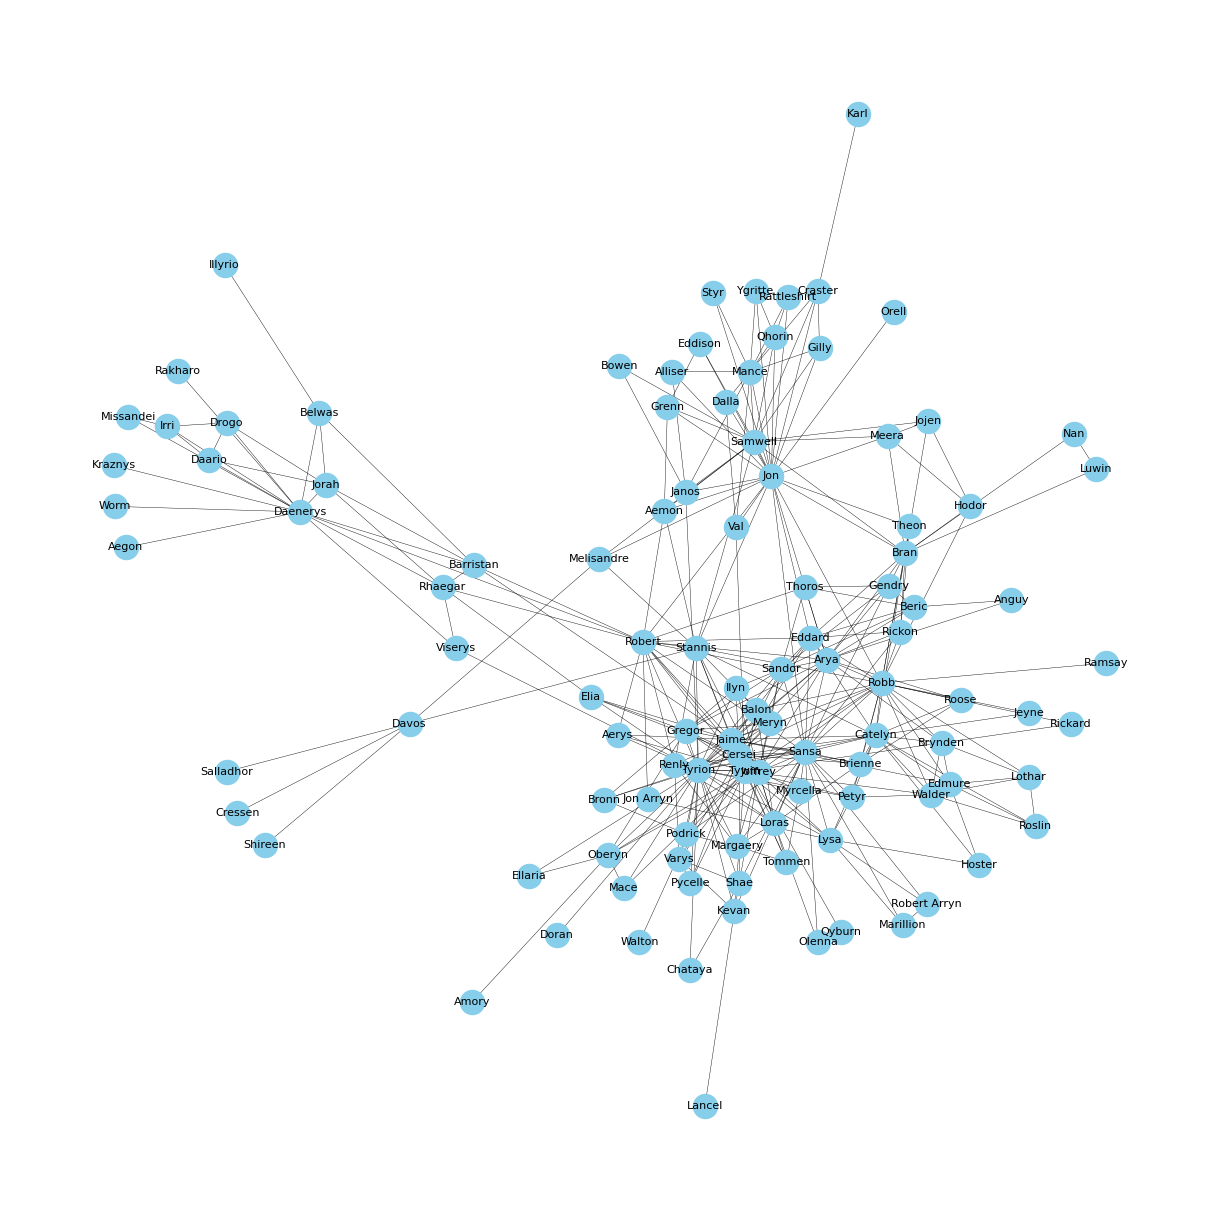

In [4]:
plt.figure(figsize=(12,12))
nx.draw(G, with_labels=True, node_color='skyblue', width=.3, font_size=8)
plt.show()

#### Calculate node degree

Make the degree values a `dict`ionary, then add it as a network "attribute" with `networkx.set_node_attributes()`

In [5]:
degrees = dict(nx.degree(G))
nx.set_node_attributes(G, name='degree', values=degrees)
for n, attr in list(G.nodes(data=True))[0:5]:
    print(f"{n} {attr}")

Aemon {'degree': 5}
Grenn {'degree': 4}
Samwell {'degree': 15}
Aerys {'degree': 4}
Jaime {'degree': 24}


Additionally, we can see the attributes of individual nodes:

In [6]:
G.nodes["Grenn"]

{'degree': 4}

Make a Pandas dataframe from the degree data `G.nodes(data='degree')`, then sort from highest to lowest

In [7]:
degree_df = pd.DataFrame(G.nodes(data='degree'), columns=['node', 'degree'])
degree_df = degree_df.sort_values(by='degree', ascending=False)
degree_df[:10]

,node,degree
6,Tyrion,36
21,Jon,26
50,Sansa,26
48,Robb,25
4,Jaime,24
7,Tywin,22
17,Cersei,20
12,Arya,19
42,Catelyn,18
20,Joffrey,18


Plot the nodes with the highest degree values

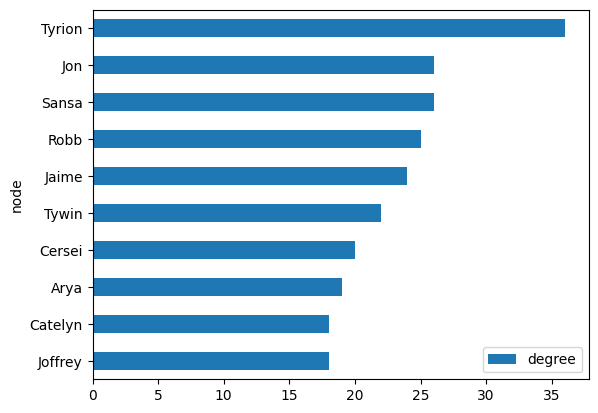

In [8]:
num_nodes_to_inspect = 10
degree_df[:num_nodes_to_inspect].plot(x='node', y='degree', kind='barh').invert_yaxis()

#### Calculate Weighted Degree

Who has the most number of connections in the network (if you factor in edge weight)?

In [ ]:
nx.degree(G, weight='Weight')

Make the weighted degree values a `dict`ionary, then add it as a network "attribute" with `networkx.set_node_attributes()`

In [ ]:
weighted_degrees = dict(nx.degree(G, weight='Weight'))
nx.set_node_attributes(G, name='weighted_degree', values=weighted_degrees)

Make a Pandas dataframe from the degree data `G.nodes(data='weighted_degree')`, then sort from highest to lowest

In [ ]:
weighted_degree_df = pd.DataFrame(G.nodes(data='weighted_degree'), columns=['node', 'weighted_degree'])
weighted_degree_df = weighted_degree_df.sort_values(by='weighted_degree', ascending=False)
weighted_degree_df[:10]

Plot the nodes with the highest weighted degree values

In [ ]:
num_nodes_to_inspect = 10
weighted_degree_df[:num_nodes_to_inspect].plot(x='node', y='weighted_degree', color='orange', kind='barh').invert_yaxis()

#### Calculate Betweenness Centrality Scores

In graph theory, betweenness centrality is a measure of centrality in a graph based on shortest paths. 
In short: How many shortest paths pass a node?
More precise: What is the fraction of a graph's shortest paths that pass a certain node?

In [ ]:
betweenness_centrality = nx.betweenness_centrality(G)

Add `betweenness_centrality` (which is already a dictionary) as a node attribute with `networkx.set_node_attributes()`

In [ ]:
nx.set_node_attributes(G, name='betweenness', values=nx.betweenness_centrality(G))

Make a Pandas dataframe from the betweenness data `G.nodes(data='betweenness')`, then sort from highest to lowest

In [ ]:
betweenness_df = pd.DataFrame(G.nodes(data='betweenness'), columns=['node', 'betweenness'])
betweenness_df = betweenness_df.sort_values(by='betweenness', ascending=False)
betweenness_df[:10]

Plot the nodes with the highest betweenness centrality scores

In [ ]:
num_nodes_to_inspect = 10
betweenness_df[:num_nodes_to_inspect].plot(x='node', y='betweenness', color='green', kind='barh').invert_yaxis()

---

### Communities

Who forms distinct communities within this network?

In [ ]:
from networkx.algorithms import community as com

Calculate communities with `community.greedy_modularity_communities()`

In [ ]:
communities = com.greedy_modularity_communities(G)
communities

"`frozenset` is an immutable version of a set. 
Like sets, it contains unique, unordered, unchangeable elements.
Unlike sets, elements cannot be added or removed from a frozenset." [W3 schools](https://www.w3schools.com/Python/python_frozenset.asp)

Make a `dict`ionary by looping through the communities and, for each member of the community, adding their community number

In [ ]:
#Create empty dictionary
modularity_class = {}
#Loop through each community in the network
for community_number, community in enumerate(communities):
    #For each member of the community, add their community number
    for name in community:
        modularity_class[name] = community_number
print(modularity_class)

Add modularity class to the network as an attribute

In [ ]:
nx.set_node_attributes(G, modularity_class, 'modularity_class')
# show first 5 nodes with their attributes
print(list(G.nodes(data=True))[:5])  

Make a Pandas dataframe from modularity class network data `G.nodes(data='modularity_class')`

In [ ]:
communities_df = pd.DataFrame(G.nodes(data='modularity_class'), columns=['node', 'modularity_class'])
communities_df = communities_df.sort_values(by='modularity_class', ascending=False)
communities_df[:10]

Inspect each community in the network

In [ ]:
communities_df[communities_df['modularity_class'] == 4][:10]

In [ ]:
communities_df[communities_df['modularity_class'] == 3][:10]

In [ ]:
communities_df[communities_df['modularity_class'] == 2][:10]

In [ ]:
communities_df[communities_df['modularity_class'] == 1][:10]

In [ ]:
communities_df[communities_df['modularity_class'] == 0][:10]

---

### All Network Metrics

Create a Pandas dataframe of all network attributes by creating a `dict`ionary of `G.nodes(data=True)` and then [transposing it](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.T.html) (flipping the columns and rows) with `.T`

In [9]:
nodes_df = pd.DataFrame(dict(G.nodes(data=True))).T
nodes_df[:10]

,degree
Aemon,5
Grenn,4
Samwell,15
Aerys,4
Jaime,24
Robert,18
Tyrion,36
Tywin,22
Alliser,3
Mance,12


In [ ]:
nodes_df.sort_values(by='betweenness', ascending=False)[:10]

---

### Serialize and deserialize a graph to/from JSON

We export our graph G to a json-encoded file. JSON is similar to a Python dict. The graph dict has the following keys: "directed" (true/false), "multigraph" (true/false), "graph" (dict of global graph attributes), "nodes", and "edges".

[{'degree': 5, 'id': 'Aemon'},
 {'degree': 4, 'id': 'Grenn'},
 {'degree': 15, 'id': 'Samwell'},
 {'degree': 4, 'id': 'Aerys'},
 {'degree': 24, 'id': 'Jaime'}]
[{'Weight': 5, 'source': 'Aemon', 'target': 'Grenn'},
 {'Weight': 31, 'source': 'Aemon', 'target': 'Samwell'},
 {'Weight': 30, 'source': 'Aemon', 'target': 'Jon'},
 {'Weight': 4, 'source': 'Aemon', 'target': 'Robert'},
 {'Weight': 4, 'source': 'Aemon', 'target': 'Stannis'}]
Graph with 107 nodes and 352 edges


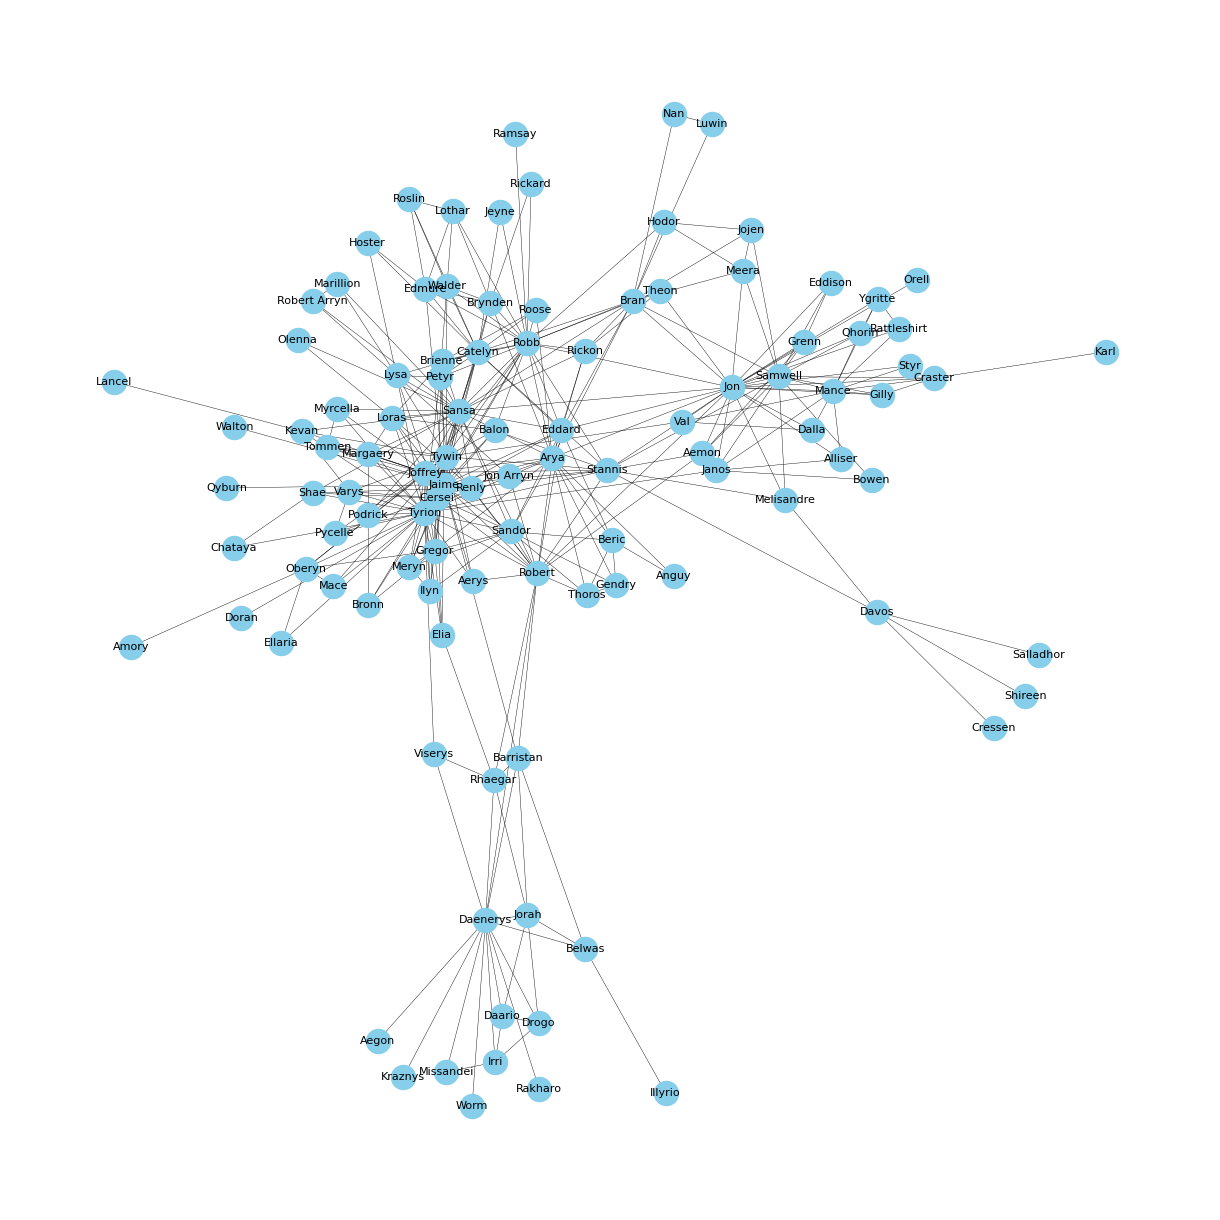

In [11]:
# Serialize to node-link format
with open('graphs/GOT_graph.json', 'w', encoding='utf-8') as f:
    json.dump(nx.node_link_data(G), f, indent=2, ensure_ascii=False)
# Deserialize from node-link format
with open('graphs/GOT_graph.json', 'r') as f:
    nl_data = json.load(f)

# Print a few nodes and edges
#pprint(nl_data["nodes"][0:5])
#pprint(nl_data["edges"][0:5])

# Reconstruct the graph
H = nx.node_link_graph(nl_data)
print(H)
plt.figure(figsize=(12,12))
nx.draw(H, with_labels=True, node_color='skyblue', width=.3, font_size=8)
plt.show()